<a href="https://colab.research.google.com/github/JYP163/awesome-chatgpt-prompts-zh/blob/main/notebooks/run_Cellpose-SAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install git+https://www.github.com/mouseland/cellpose.git

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-2umvpvje
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-2umvpvje
  Resolved https://www.github.com/mouseland/cellpose.git to commit 6d23968d924fc3b8e419a2d79349888f4b07aa29
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 69.2 MB/s eta 0:00:00
  Created wheel for cellpose: filename=cellpose-4.0.9.dev5+g6d23968d9-py3-none-any.whl size=212314 sha256=8d63ce8d59835676ce86805a6d87c9c4485f60c32e4a07e2502a990f8bbcf010
  Stored in directory: /tmp/pip-ephem-wheel-cache-tumkcsmw/wheels/df/b6/31/a3013c44290eabb46f4c06d1efb19744124fcad2d59684ec5e
Successfully built cellpose


In [6]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

creating new log file
2026-02-01 13:07:40,330 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-02-01 13:07:40,331 [INFO] 
cellpose version: 	4.0.9.dev5+g6d23968d9 
platform:       	linux 
python version: 	3.12.12 
torch version:  	2.9.0+cu126
2026-02-01 13:07:40,579 [INFO] ** TORCH CUDA version installed and working. **
2026-02-01 13:07:40,581 [INFO] ** TORCH CUDA version installed and working. **
2026-02-01 13:07:40,582 [INFO] >>>> using GPU (CUDA)
2026-02-01 13:07:43,707 [INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam" to /root/.cellpose/models/cpsam



100%|██████████| 1.15G/1.15G [00:19<00:00, 64.5MB/s]


**Input directory with your images:**

In [7]:
# *** change to your google drive folder path ***
dir = "/content/drive/MyDrive/pictures/2026-1-30/sh-pcmt1-2/拍摄-1240-图像导出-01-1"
dir = Path(dir)
if not dir.exists():
  raise FileNotFoundError("directory does not exist")

# *** change to your image extension ***
image_ext = ".tif"

# list all files
files = natsorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])

if(len(files)==0):
  raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
else:
  print(f"{len(files)} images in folder:")

for f in files:
  print(f.name)

1 images in folder:
拍摄-1240-图像导出-012.tif


In [8]:
img = io.imread(files[0])

print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')

your image has shape: (2464, 2056, 3). Assuming channel dimension is last with 3 channels


In [9]:
first_channel = '1' # @param ['None', 0, 1, 2, 3, 4, 5]
second_channel = '2' # @param ['None', 0, 1, 2, 3, 4, 5]
third_channel = 'None' # @param ['None', 0, 1, 2, 3, 4, 5]

2026-02-01 13:08:42,743 [INFO] processing image with (2464, 2056) HW, and 3 channels


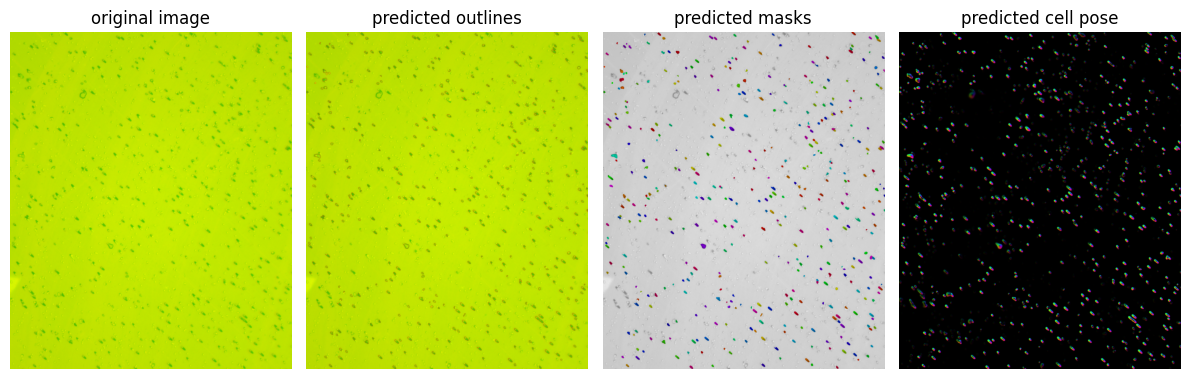

In [10]:
selected_channels = []
for i, c in enumerate([first_channel, second_channel, third_channel]):
  if c == 'None':
    continue
  if int(c) > img.shape[-1]:
    assert False, 'invalid channel index, must have index greater or equal to the number of channels'
  if c != 'None':
    selected_channels.append(int(c))



img_selected_channels = np.zeros_like(img)
img_selected_channels[:, :, :len(selected_channels)] = img[:, :, selected_channels]


flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

masks, flows, styles = model.eval(img_selected_channels, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
plt.tight_layout()
plt.show()


🚀 开始批量分割与计数...


  0%|          | 0/1 [00:00<?, ?it/s]

2026-02-01 13:15:40,104 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-02-01 13:15:40,110 [INFO] processing image with (2464, 2056) HW, and 3 channels

图片 [1/1]: 拍摄-1240-图像导出-012.tif | 找到 411 个细胞


100%|██████████| 1/1 [00:47<00:00, 47.52s/it]


✅ 保存成功: /content/drive/MyDrive/output-pictures/拍摄-1240-图像导出-012_masks.png

✅ 全部完成！
📊 计数汇总已存至: /content/drive/MyDrive/pictures/2026-1-30/sh-pcmt1-2/拍摄-1240-图像导出-01-1/细胞计数汇总表.csv
🖼️ 请在文件夹中查看 '_彩色预览.jpg' 以确认分割效果。


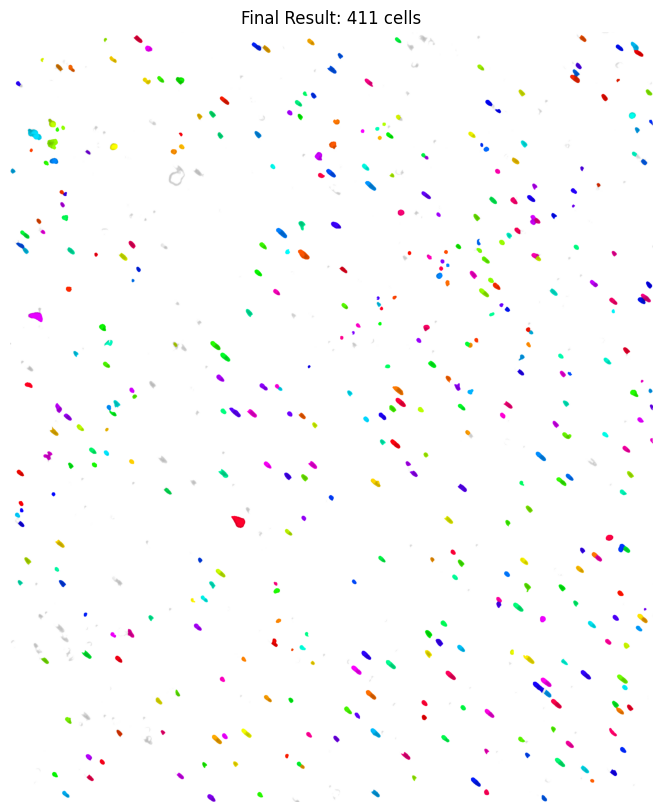

In [13]:
import numpy as np
import pandas as pd
from cellpose import plot, io as cp_io
import matplotlib.pyplot as plt

# --- 1. 参数设置 ---
# 根据你之前的情况，核通道在索引 1 (second_channel)
# Cellpose channels = [主通道(胞质), 辅助通道(核)]
# 如果只用核计数，建议设置为 [1, 0] 或 [2, 1]
safe_channels = [1, 2]
results = [] # 用于存储所有图片的计数结果

print("🚀 开始批量分割与计数...")

for i in trange(len(files)):
    f = files[i]
    img = io.imread(f)

    # --- 2. 运行 Cellpose 核心预测 ---
    # 删除了不支持的 tile 参数，保持 model.eval 纯净
    masks, flows, styles = model.eval(img, diameter=None, channels=safe_channels)

    # --- 3. 统计计数 ---
    cell_count = np.max(masks)
    results.append({"文件名": f.name, "细胞数量": cell_count})
    print(f"\n图片 [{i+1}/{len(files)}]: {f.name} | 找到 {cell_count} 个细胞")

    # --- 4. 生成“看得见”的分割效果图 ---
    # 这步是将彩色掩膜叠加在原图上，方便你检查分得准不准
    view_img = plot.mask_overlay(img, masks)
    preview_path = dir / (f.stem + "_彩色预览.jpg")
    io.imsave(preview_path, view_img)

import os
from pathlib import Path

# --- 设置自定义保存路径 ---
# 在这里填入你想保存的文件夹路径
custom_save_path = "/content/drive/MyDrive/output-pictures"
output_dir = Path(custom_save_path)

# 确保文件夹存在，如果不存在则自动创建
output_dir.mkdir(parents=True, exist_ok=True)

# --- 5. 保存数据结果 ---
# 1. 这里补充定义 masks_ext (如果你想要 tif 格式，就改成 ".tif")
masks_ext = ".png"

    # 2. 保存原始 Mask (给电脑读的黑白图)
mask_path = output_dir / (f.stem + "_masks" + masks_ext)
io.imsave(mask_path, masks)

    # 3. 修正后的 ROI 保存 (使用 cellpose.io)
try:
    target_file_path = output_dir / f.name
    cp_io.save_rois(masks, target_file_path)
    print(f"✅ 保存成功: {mask_path}")
except Exception as e:
    print(f"⚠️ ROI保存失败: {e}")

# --- 6. 导出汇总表到 Excel (CSV) ---
df = pd.DataFrame(results)
summary_path = dir / "细胞计数汇总表.csv"
df.to_csv(summary_path, index=False, encoding='utf_8_sig')

print(f"\n✅ 全部完成！")
print(f"📊 计数汇总已存至: {summary_path}")
print(f"🖼️ 请在文件夹中查看 '_彩色预览.jpg' 以确认分割效果。")

# 在屏幕上直接展示最后一张图的效果
plt.figure(figsize=(10, 10))
plt.imshow(view_img)
plt.title(f"Final Result: {cell_count} cells")
plt.axis('off')
plt.show()